In [1]:
import random
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

cols = ['ts', 'next_ts', 'ttl', 'create_ts', 'freq', 'last_ts', 'update_ts', 'revals', 'good_rv', 'bad_rv', 'mime']
dfs = [pd.read_csv(f'../traces/expiry/cf_{c}.csv.zst', names=cols, skiprows=lambda i: random.random() > 0.05) for c in ['a', 'c']]
df = pd.concat(dfs)
df

,ts,next_ts,ttl,create_ts,freq,last_ts,update_ts,revals,good_rv,bad_rv,mime
0,8,0,6,1,1,1,1,0,0,0,6
1,12,17,7,4,2,10,4,0,0,0,3
2,20,28,7,4,1,17,12,1,1,0,3
3,24,180793,6,17,1,17,17,0,0,0,6
4,28,0,6,21,1,21,21,0,0,0,6
...,...,...,...,...,...,...,...,...,...,...,...
2586091,2764798,0,60,2764615,1,2764789,2764737,11890,11890,0,3
2586092,2764798,0,1200,2763597,2,2764247,2763597,301323,299768,1554,3
2586093,2764799,0,1800,2762998,1,2762998,2762998,43006,43006,0,19
2586094,2764799,0,14400,2750398,2,2751243,2750398,1585,1585,0,15


In [15]:
df['should_reval'] = (df['ts'] <= df['next_ts']) & (df['next_ts'] <= (df['ts'] + df['ttl'])) & (df['ttl'] < 7 * 86400)
df['generations'] = ((df['ts'] - df['create_ts'] - 1) / df['ttl']).round()
df['t_since_last'] = df['ts'] - df['last_ts']
df['t_since_last_frac'] = (df['t_since_last'] - 1)/ df['ttl']
df_good = df[df['should_reval']]
df_bad = df[~df['should_reval']].sample(n=len(df_good), random_state=42)
len(df_good), len(df_bad)

(846295, 846295)

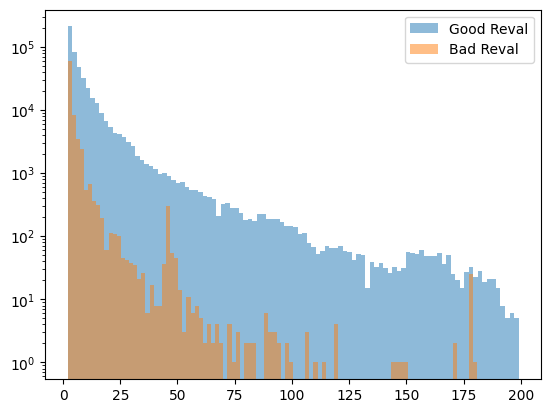

In [26]:
plt.hist(df_good[(df_good['generations'] > 1) & (df_good['generations'] < 200)]['generations'], label='Good Reval', alpha=0.5, bins=100)
plt.hist(df_bad[(df_bad['generations'] > 1) & (df_bad['generations'] < 200)]['generations'], label='Bad Reval', alpha=0.5, bins=100)
plt.yscale('log')
plt.legend()

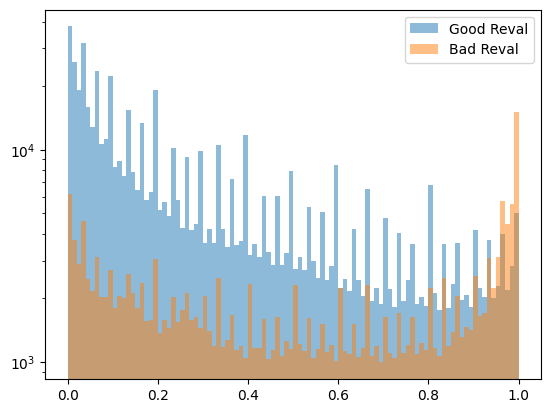

In [16]:
plt.hist(df_good[(df_good['t_since_last_frac'] > 0) & (df_good['t_since_last_frac'] < 1)]['t_since_last_frac'], label='Good Reval', alpha=0.5, bins=100)
plt.hist(df_bad[(df_bad['t_since_last_frac'] > 0) & (df_bad['t_since_last_frac'] < 1)]['t_since_last_frac'], label='Bad Reval', alpha=0.5, bins=100)
plt.yscale('log')
plt.legend()